# VDP vs digest2 — ROC Comparison

Head-to-head comparison of the VDP probability-map classifier vs digest2 on the same S3M objects. The corrected comparison uses the VDP map geometry: a circular sky patch centered at geocentric ecliptic `(lon, lat) = (180°, 0°)` with radius `30°`, apparent magnitude `14–26`, epoch `2025-03-21`, and Rubin Observatory/X05 two-point 30-minute tracklets for digest2.

**Fast path (recommended):** Run section 2 onward — loads the pre-computed parquet.

**Full re-run:** Run `run_digest2_comparison.py` first. The script propagates the S3M populations, scores VDP, runs digest2 in chunks, and writes the parquet used here.


In [1]:
# Optional: re-run the full pipeline from this notebook (slow)
# The script now chunks digest2 calls, so the full run can take about an hour.
# %run run_digest2_comparison.py


## 1. Setup

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
import velocity_density_pipeline as vdp

_HERE = os.path.dirname(os.path.abspath('__file__'))
PARQUET = os.path.join(_HERE, 's3m_digest2_comparison.parquet')
PROB_MAPS = os.path.join(_HERE, 'prob_maps_2025-03-21.npz')
FIG_OUT  = os.path.join(_HERE, 'roc_comparison_vdp_digest2.png')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 2. Load results

In [3]:
df = pd.read_parquet(PARQUET)
print(f'{len(df):,} objects')
print(df['true_population'].value_counts().to_string())

pops = sorted(df['true_population'].unique())
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}
df.head()

38,045 objects
true_population
MBA        15350
Trojans    13035
TNO         7427
NEO         2233


,true_population,lam_deg,vlam,vbeta,mag_app,H,P_NEO_vdp,P_NEO_d2
0,NEO,188.213266,-0.224582,0.020553,18.110710,11.452,0.000399,0.41
1,NEO,169.925547,-0.346591,0.053089,16.340715,12.430,0.701057,0.96
2,NEO,190.416689,-0.385974,-0.013405,17.992193,13.901,0.830255,1.00
3,NEO,163.777123,-0.258691,0.032913,18.760917,14.092,0.000599,0.60
4,NEO,175.908696,-0.274626,-0.008760,20.302876,15.092,0.008860,0.15


**Dataset note.** This parquet is the corrected four-population comparison sample. Objects first pass the VDP map sky-patch selection and magnitude range, then the same objects are scored by VDP and by digest2. Because the corrected sample includes MBAs, NEOs, TNOs, and Trojans, the results test more than simple NEO-vs-MBA separation.

In [4]:
# Re-score VDP from the probability maps (in case you want fresh scores)
pm = vdp.ProbMapSet.from_npz(PROB_MAPS)
probs = pm.score_visible(df.vlam.to_numpy(), df.vbeta.to_numpy(), df.mag_app.to_numpy())
df['P_NEO_vdp'] = probs['NEO']
df['P_MBA_vdp'] = probs['MBA']
df['P_TNO_vdp'] = probs['TNO']
df['P_Troj_vdp'] = probs['Trojans']
print('VDP P_NEO range:', round(float(df.P_NEO_vdp.min()), 4), '–', round(float(df.P_NEO_vdp.max()), 4))
print('sum check (should be ≤1):', (df.P_NEO_vdp + df.P_MBA_vdp + df.P_TNO_vdp + df.P_Troj_vdp).describe())

VDP P_NEO range: 0.0 – 0.9986
sum check (should be ≤1): count    38045.000000
mean         0.999344
std          0.015914
min          0.153467
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64


## 3. Score distributions

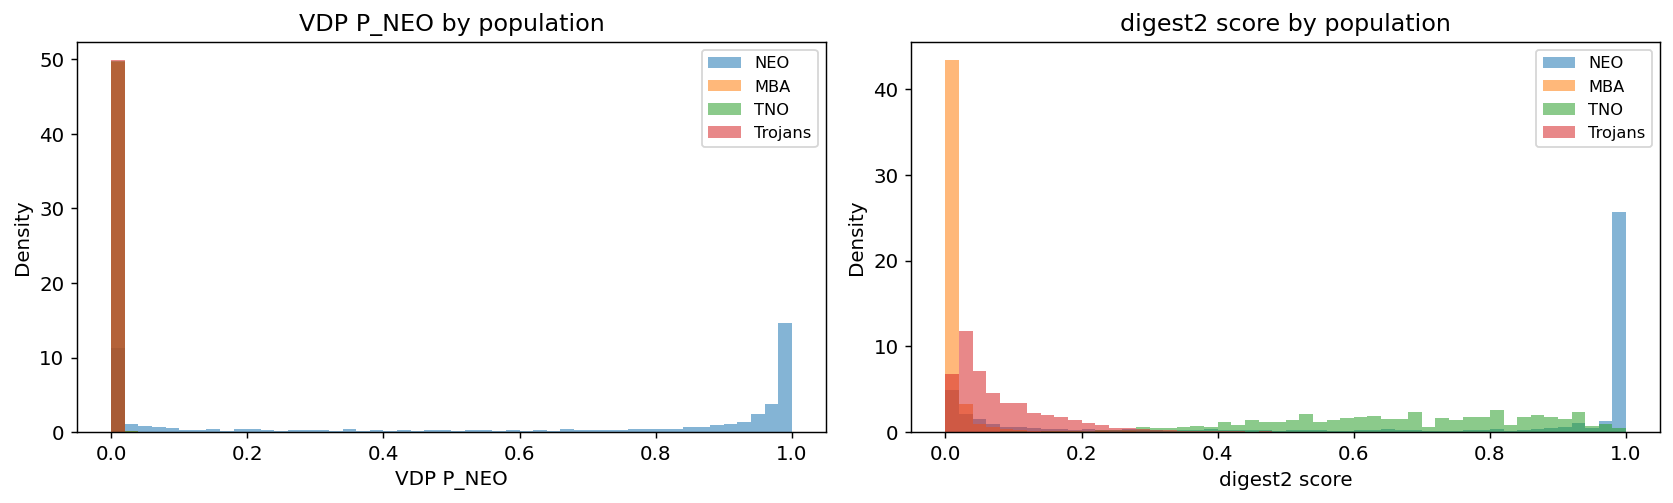

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pops = df['true_population'].unique()
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}

for ax, (col, label) in zip(axes, [('P_NEO_vdp', 'VDP P_NEO'), ('P_NEO_d2', 'digest2 score')]):
    for pop in pops:
        sub = df.loc[df.true_population == pop, col]
        ax.hist(sub, bins=50, alpha=0.55, label=pop, color=colors.get(pop),
                density=True, range=(0, 1))
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.set_title(f'{label} by population')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
plt.close(fig)

**Score distribution interpretation.** VDP strongly concentrates MBAs, TNOs, and Trojans near `P_NEO = 0`, while many true NEOs cluster near high probability. digest2 also gives many NEOs high scores, but its output is more discretized and saturated near `1.0`. In this synthetic four-population sample, digest2 also assigns elevated NEO scores to many TNOs, which is why its clean operating threshold becomes very strict.

The TNO behavior should be read as a conditional classifier test: these are TNOs that are present in the simulated comparison sample and are passed to digest2 as Rubin/X05 tracklets. This does not imply that real NEOCP submissions would contain TNOs at the same rate, since distant and slow TNOs are less likely to enter the NEOCP candidate stream.

## 4. ROC curves

In [6]:
is_neo = (df['true_population'] == 'NEO').to_numpy()
N_neo  = is_neo.sum()
N_non  = (~is_neo).sum()
print(f'N_NEO={N_neo}  N_non-NEO={N_non}')

thresholds = np.linspace(0, 1, 401)

def compute_roc(scores, is_neo, thresholds):
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))
    for j, t in enumerate(thresholds):
        above = scores > t
        tp = above[is_neo].sum()
        fp = above[~is_neo].sum()
        comp[j] = tp / max(N_neo, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont

def best_f1(comp, cont, thr):
    pur = 1 - cont
    f1  = np.where(pur + comp > 0, 2*pur*comp/(pur + comp + 1e-12), 0.0)
    i   = np.argmax(f1)
    return thr[i], comp[i], cont[i], f1[i]

comp_v, cont_v = compute_roc(df['P_NEO_vdp'].to_numpy(), is_neo, thresholds)
comp_d, cont_d = compute_roc(df['P_NEO_d2'].to_numpy(),  is_neo, thresholds)

tv, cv, nv, fv = best_f1(comp_v, cont_v, thresholds)
td, cd, nd, fd = best_f1(comp_d, cont_d, thresholds)

print(f'VDP     best: t={tv:.3f}  completeness={cv:.1%}  contamination={nv:.1%}  F1={fv:.3f}')
print(f'Digest2 best: t={td:.3f}  completeness={cd:.1%}  contamination={nd:.1%}  F1={fd:.3f}')

N_NEO=2233  N_non-NEO=35812
VDP     best: t=0.028  completeness=76.7%  contamination=6.0%  F1=0.845
Digest2 best: t=0.970  completeness=51.3%  contamination=6.4%  F1=0.663


**Threshold and F1 interpretation.** Each classifier is converted into a binary NEO selector by applying a score threshold: `score > t`. Completeness is the fraction of true NEOs recovered, while contamination is the fraction of selected candidates that are not NEOs. Purity is therefore `1 - contamination`.

`F1` is a single summary score that balances completeness and purity:

```text
F1 = 2 * purity * completeness / (purity + completeness)
```

A high F1 means the classifier is both complete and clean. Here VDP reaches much higher NEO completeness at similar contamination, so its F1 is higher than digest2's.

Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/roc_comparison_vdp_digest2.png

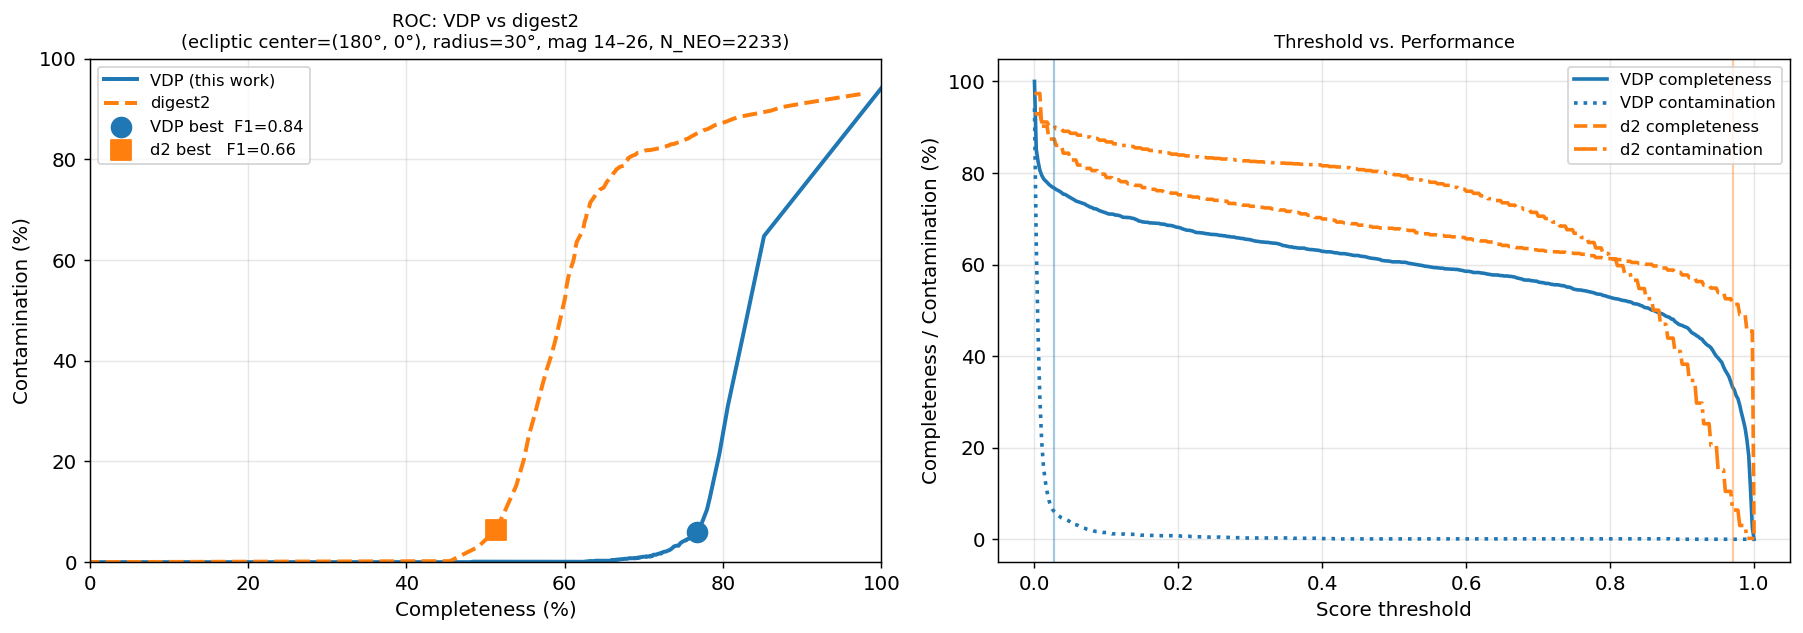

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(comp_v*100, cont_v*100, lw=2.2, color='tab:blue',   label='VDP (this work)')
ax.plot(comp_d*100, cont_d*100, lw=2.2, color='tab:orange', linestyle='--', label='digest2')
ax.scatter([cv*100], [nv*100], color='tab:blue',   s=120, zorder=5, label=f'VDP best  F1={fv:.2f}')
ax.scatter([cd*100], [nd*100], color='tab:orange', s=120, zorder=5, marker='s', label=f'd2 best   F1={fd:.2f}')
ax.set_xlabel('Completeness (%)'); ax.set_ylabel('Contamination (%)')
ax.set_title(f'ROC: VDP vs digest2\n(ecliptic center=(180°, 0°), radius=30°, mag 14–26, N_NEO={N_neo})', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
ax.plot(thresholds, comp_v*100, lw=2,   color='tab:blue',   label='VDP completeness')
ax.plot(thresholds, cont_v*100, lw=2,   color='tab:blue',   linestyle=':', label='VDP contamination')
ax.plot(thresholds, comp_d*100, lw=2,   color='tab:orange', linestyle='--', label='d2 completeness')
ax.plot(thresholds, cont_d*100, lw=2,   color='tab:orange', linestyle='-.', label='d2 contamination')
ax.axvline(tv, color='tab:blue',   alpha=0.4, lw=1.2)
ax.axvline(td, color='tab:orange', alpha=0.4, lw=1.2)
ax.set_xlabel('Score threshold'); ax.set_ylabel('Completeness / Contamination (%)')
ax.set_title('Threshold vs. Performance', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
print(f'Saved: {FIG_OUT}')
plt.show()
plt.close(fig)

**ROC interpretation.** The ideal point is the lower-right corner: high completeness and low contamination. The VDP curve stays lower than digest2 at high completeness, meaning VDP can recover more true NEOs before admitting many false positives. digest2 can remain clean only at a very high threshold, but that conservative threshold rejects many real NEOs.

## 5. Per-population score breakdown

In [8]:
for pop in sorted(df.true_population.unique()):
    sub = df[df.true_population == pop]
    vdp_med = sub.P_NEO_vdp.median()
    d2_med  = sub.P_NEO_d2.median()
    vdp_hi  = (sub.P_NEO_vdp > tv).mean()
    d2_hi   = (sub.P_NEO_d2  > td).mean()
    print(f'{pop:10s}  n={len(sub):4d}  '
          f'VDP median={vdp_med:.3f}  above_thr={vdp_hi:.1%}  '
          f'| d2 median={d2_med:.3f}  above_thr={d2_hi:.1%}')

MBA         n=15350  VDP median=0.000  above_thr=0.5%  | d2 median=0.010  above_thr=0.0%
NEO         n=2233  VDP median=0.860  above_thr=76.7%  | d2 median=0.980  above_thr=51.3%
TNO         n=7427  VDP median=0.002  above_thr=0.1%  | d2 median=0.670  above_thr=1.1%
Trojans     n=13035  VDP median=0.000  above_thr=0.2%  | d2 median=0.050  above_thr=0.0%


**Per-population interpretation.** `above_thr` is the fraction of each true population that would be selected as a NEO candidate at the best threshold. VDP recovers most NEOs while allowing only tiny fractions of MBAs, TNOs, and Trojans through. digest2 rejects MBAs and Trojans at its strict threshold, but its threshold must be near `1.0` because TNOs often receive high digest2 scores; this reduces the fraction of true NEOs that pass.

## 6. Explore: score vs. observable properties

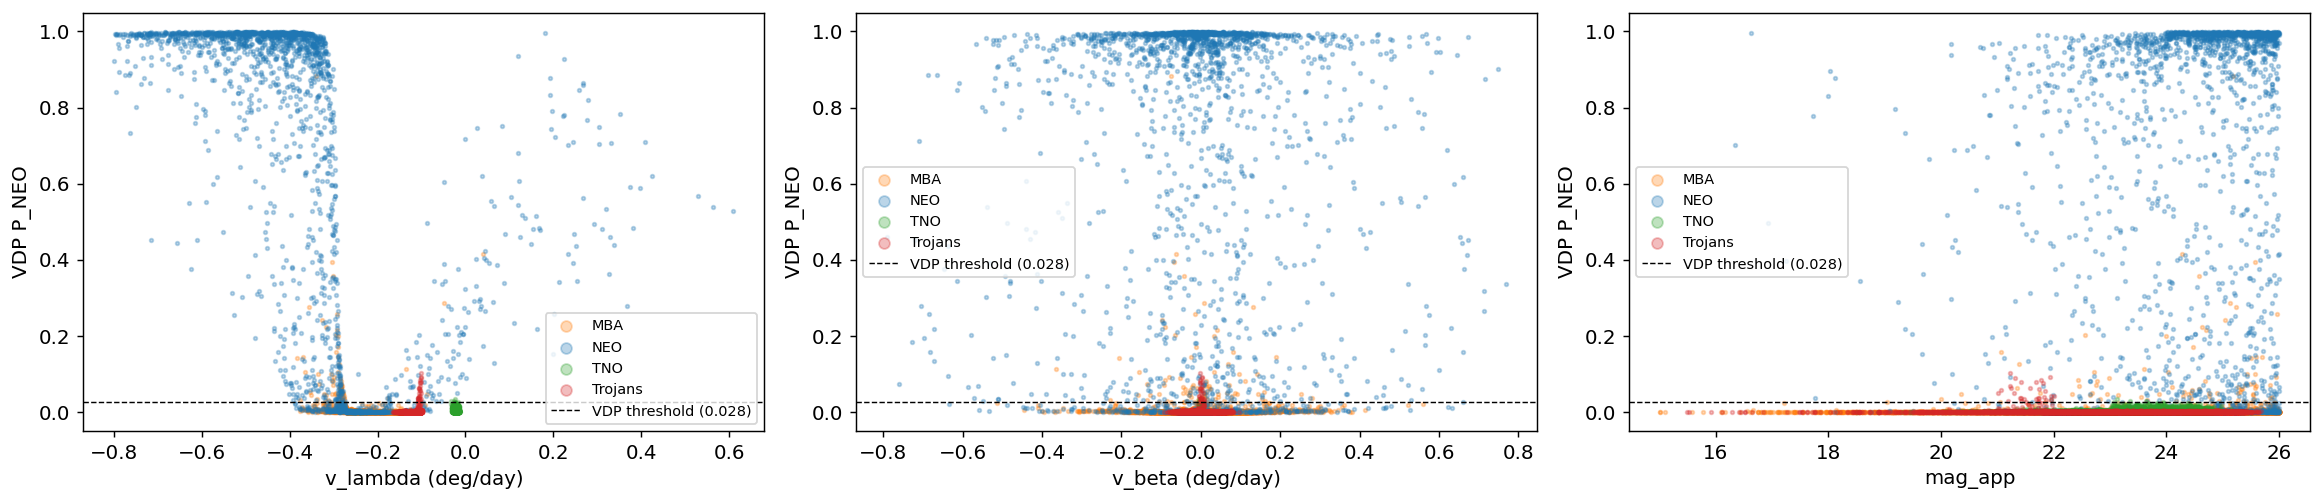

In [9]:
pops = sorted(df['true_population'].unique())
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mag_app', 'mag_app')]
):
    for pop in pops:
        sub = df[df.true_population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=4, alpha=0.3,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)


**VDP vs observables.** VDP uses `v_lambda`, `v_beta`, and `mag_app` through magnitude-binned velocity-density maps. The clearest visual separation is in `v_lambda`: NEOs occupy a faster, more negative longitudinal-motion region, while most MBAs, TNOs, and Trojans remain near zero VDP probability. `v_beta` adds out-of-ecliptic motion information, but by itself it is less cleanly separating. Magnitude selects the relevant map bin rather than acting as a standalone classifier; non-NEOs at similar magnitudes can still receive near-zero VDP probability.

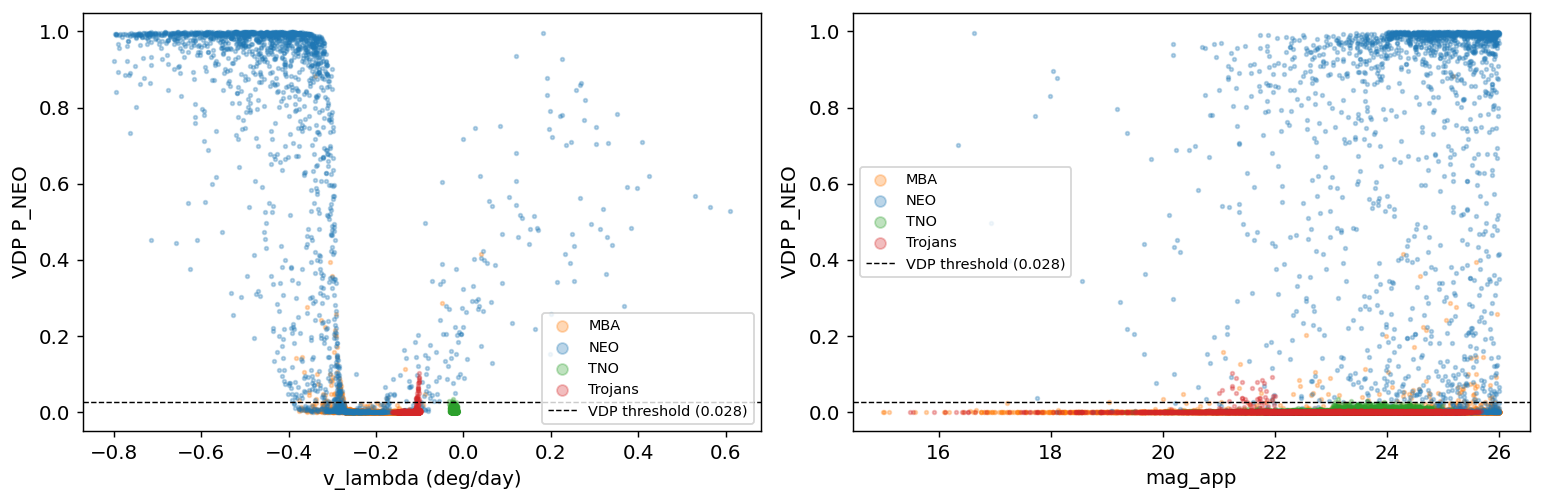

In [10]:
# Poster-friendly VDP observable view: v_lambda and magnitude only
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('mag_app', 'mag_app')]
):
    for pop in pops:
        sub = df[df.true_population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=4, alpha=0.3,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)


**Poster-friendly VDP view.** This version drops `v_beta` and keeps the two most presentation-useful panels: `v_lambda`, where the NEO-like velocity separation is clearest, and `mag_app`, which shows that magnitude alone is not driving the classification. The same VDP threshold is shown for consistency.

### 7. Explore: digest2 score vs. observable properties

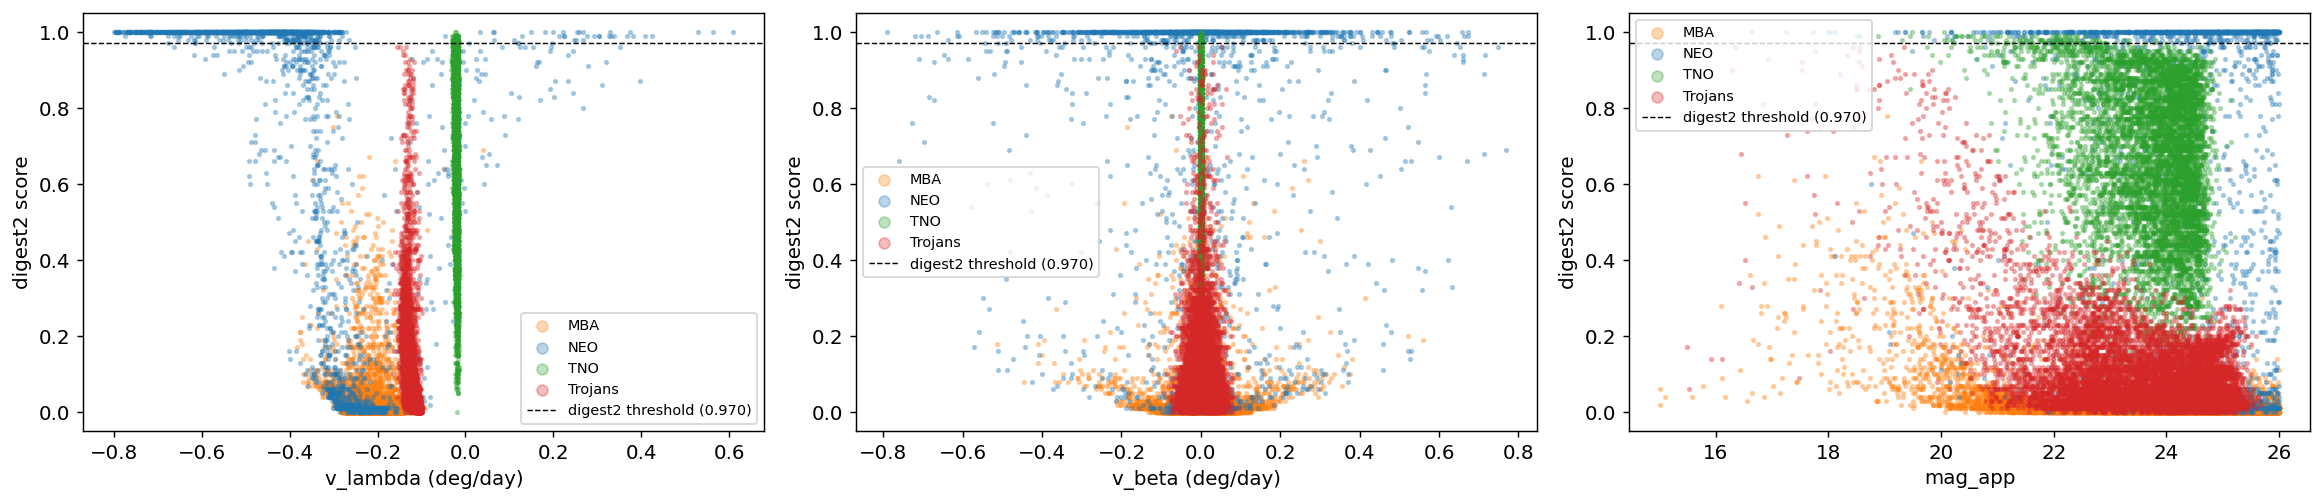

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mag_app', 'mag_app')]
):
    for pop in pops:
        sub = df[df.true_population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_d2'], s=4, alpha=0.3,
                   label=pop, color=colors.get(pop))
    ax.axhline(td, color='k', lw=0.8, linestyle='--', label=f'digest2 threshold ({td:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('digest2 score')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)

**digest2 vs observables.** These panels do not imply that digest2 internally uses ecliptic `v_lambda` and `v_beta` in the same way VDP does. digest2 receives MPC-style tracklets, so the angular motion is encoded through two timed positions and the observatory code. Plotting digest2 score against the same observables is still useful diagnostically: it shows where digest2 assigns high NEO scores in the VDP feature space.

In this corrected sample, digest2 assigns high scores to many true NEOs, but also to a substantial TNO population at faint magnitudes and near low out-of-plane motion. To keep contamination low, the best digest2 threshold is therefore very close to `1.0`, which sacrifices NEO completeness.